In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data=pd.read_csv('Bank_Customer_Churn_Dataset.csv')

### Understand the Dataset

In [33]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [34]:
data.shape

(10000, 14)

In [35]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [37]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Data Quality Check

In [38]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [39]:
data.duplicated().sum()

0

In [40]:
for col in data.select_dtypes(include='object').columns:
    print('\n',col)
    print(data[col].unique())


 Surname
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

 Geography
['France' 'Spain' 'Germany']

 Gender
['Female' 'Male']


## Data Cleaning

In [41]:
data = data.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
).copy()

In [42]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

In [43]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

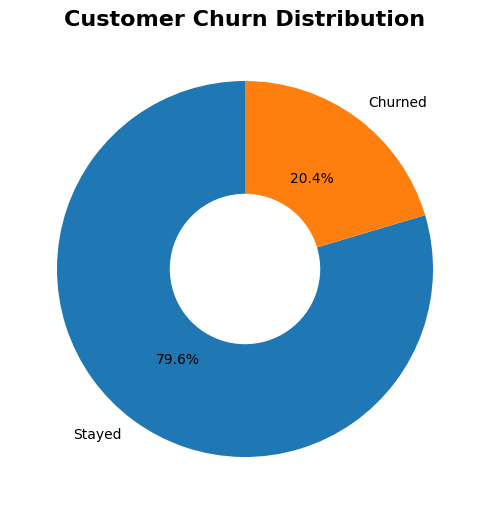

In [44]:
churn_counts = data["Exited"].value_counts()

plt.figure(figsize=(5, 6))

plt.pie(
    churn_counts,
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.60)
)

plt.title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

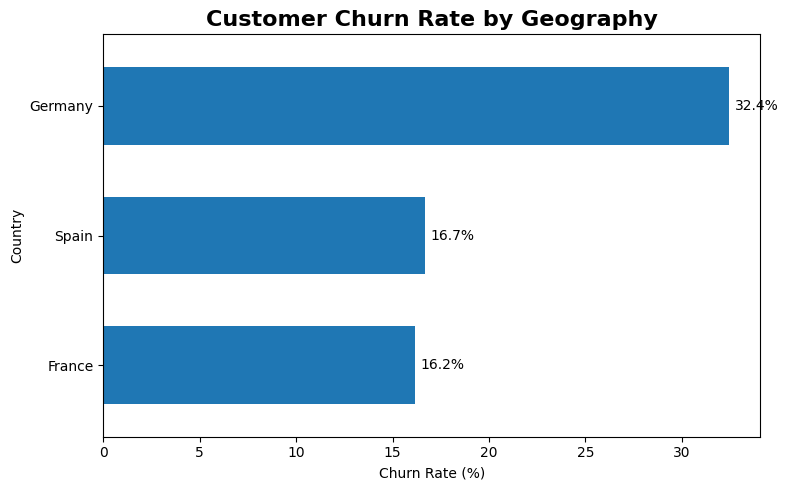

In [45]:
geo_churn = (
    data.groupby("Geography")["Exited"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

ax = geo_churn.plot(
    kind="barh",
    width=0.6
)

for i, value in enumerate(geo_churn):
    ax.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.title(
    "Customer Churn Rate by Geography",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

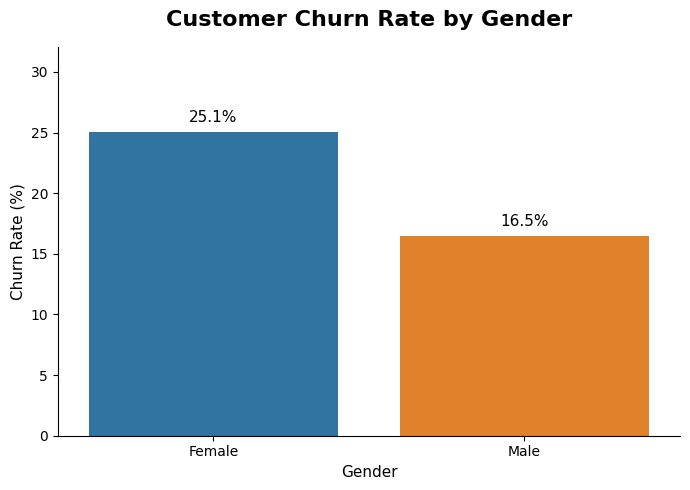

In [46]:

# Calculate churn rate
gender_churn = data.groupby("Gender")["Exited"].mean().reset_index()
gender_churn["Exited"] = gender_churn["Exited"] * 100

# Create figure
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Exited",
    hue="Gender",
    legend=False,
    errorbar=None
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=11
    )

# Formatting
plt.title(
    "Customer Churn Rate by Gender",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Gender", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)

plt.ylim(0, max(gender_churn["Exited"]) + 7)

sns.despine()
plt.tight_layout()

plt.show()

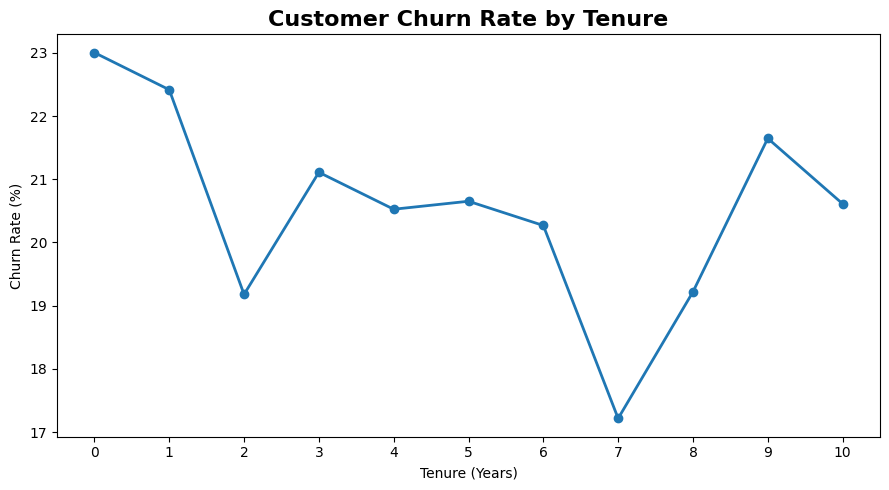

In [47]:
tenure_churn = (
    data.groupby("Tenure")["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Customer Churn Rate by Tenure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")

plt.xticks(range(0, 11))

plt.tight_layout()
plt.show()

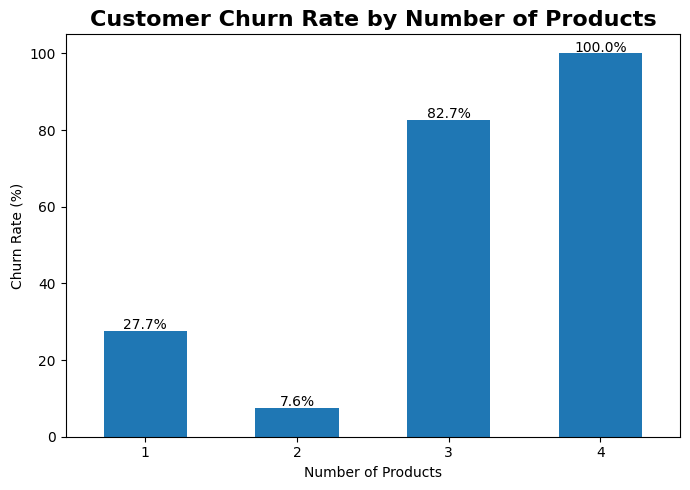

In [48]:
product_churn = (
    data.groupby("NumOfProducts")["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

ax = product_churn.plot(
    kind="bar",
    width=0.55
)

for i, value in enumerate(product_churn):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.title(
    "Customer Churn Rate by Number of Products",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

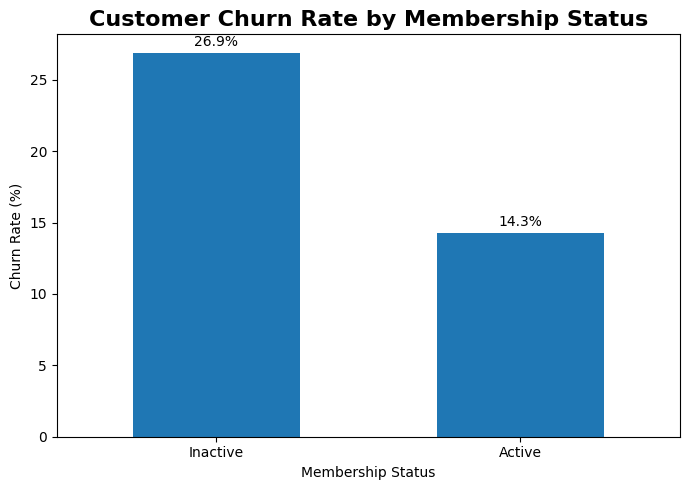

In [49]:
active_churn = (
    data.groupby("IsActiveMember")["Exited"]
    .mean()
    .mul(100)
)

active_churn.index = [
    "Inactive",
    "Active"
]

plt.figure(figsize=(7, 5))

ax = active_churn.plot(
    kind="bar",
    width=0.55
)

for i, value in enumerate(active_churn):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.title(
    "Customer Churn Rate by Membership Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Membership Status")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

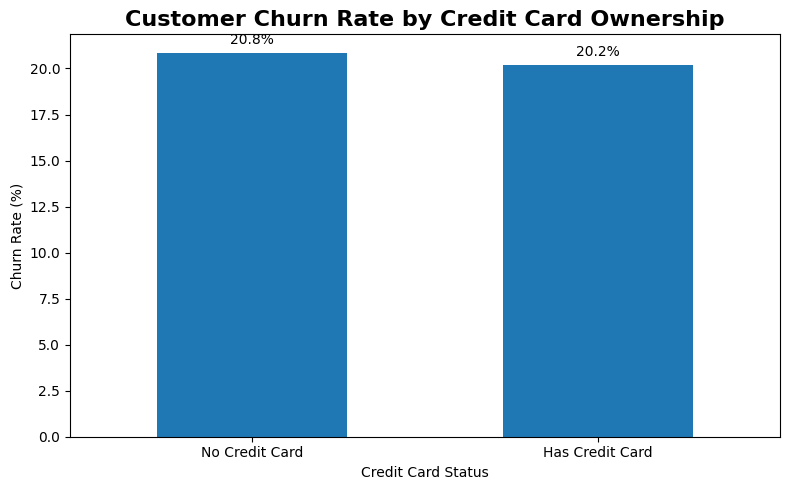

In [50]:
card_churn = (
    data.groupby("HasCrCard")["Exited"]
    .mean()
    .mul(100)
)

card_churn.index = [
    "No Credit Card",
    "Has Credit Card"
]

plt.figure(figsize=(8, 5))

ax = card_churn.plot(
    kind="bar",
    width=0.55
)

for i, value in enumerate(card_churn):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.title(
    "Customer Churn Rate by Credit Card Ownership",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Credit Card Status")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

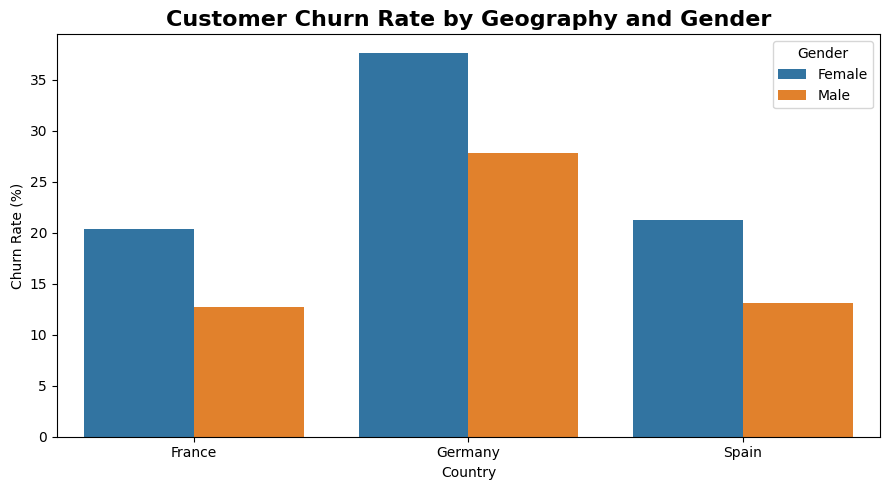

In [51]:
geo_gender = (
    data.groupby(
        ["Geography", "Gender"]
    )["Exited"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=geo_gender,
    x="Geography",
    y="Exited",
    hue="Gender"
)

plt.title(
    "Customer Churn Rate by Geography and Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

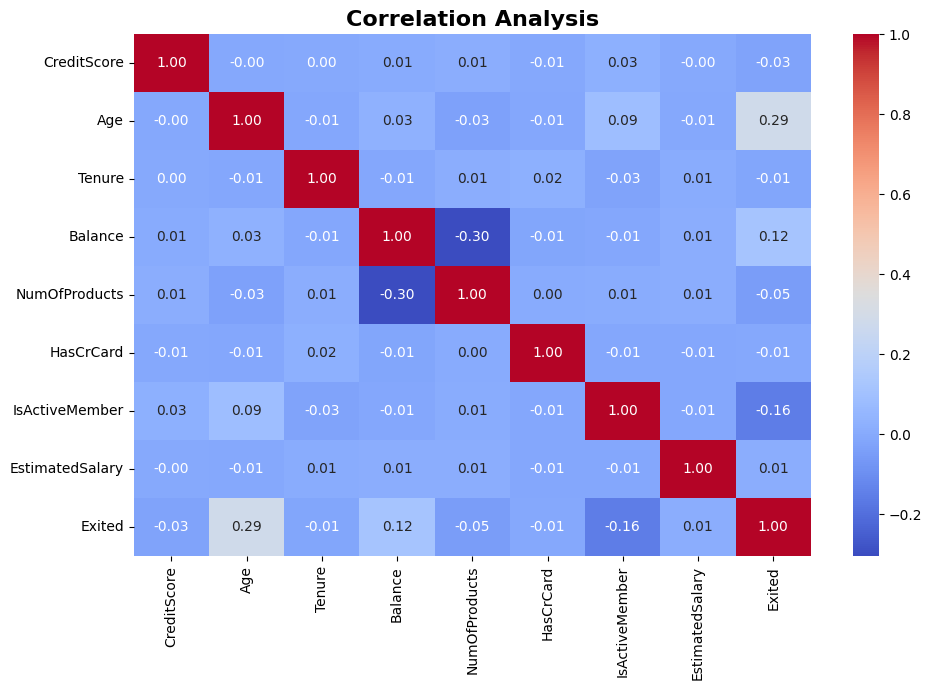

In [52]:
numeric_data = data.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Feature Engineering

In [53]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "18–25",
        "26–35",
        "36–45",
        "46–55",
        "56–65",
        "66+"
    ]
)

In [54]:
data["BalanceCategory"] = pd.cut(
    data["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, np.inf],
    labels=[
        "Zero Balance",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [55]:
data["CreditScoreGroup"] = pd.cut(
    data["CreditScore"],
    bins=[0, 580, 670, 740, 800, 900],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

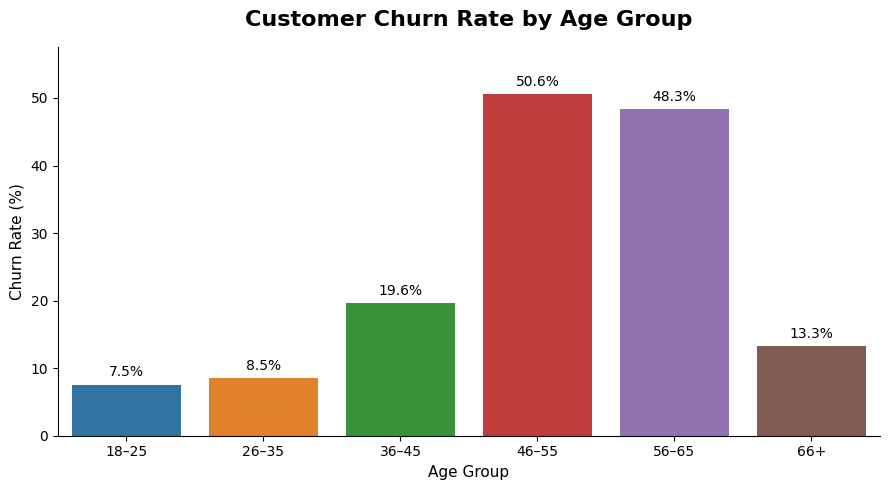

In [56]:
age_churn = (
    data.groupby("AgeGroup", observed=True)["Exited"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=age_churn,
    x="AgeGroup",
    y="Exited",
    hue="AgeGroup",
    legend=False,
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=10
    )

plt.title(
    "Customer Churn Rate by Age Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)

plt.ylim(0, age_churn["Exited"].max() + 7)

sns.despine()
plt.tight_layout()

plt.show()

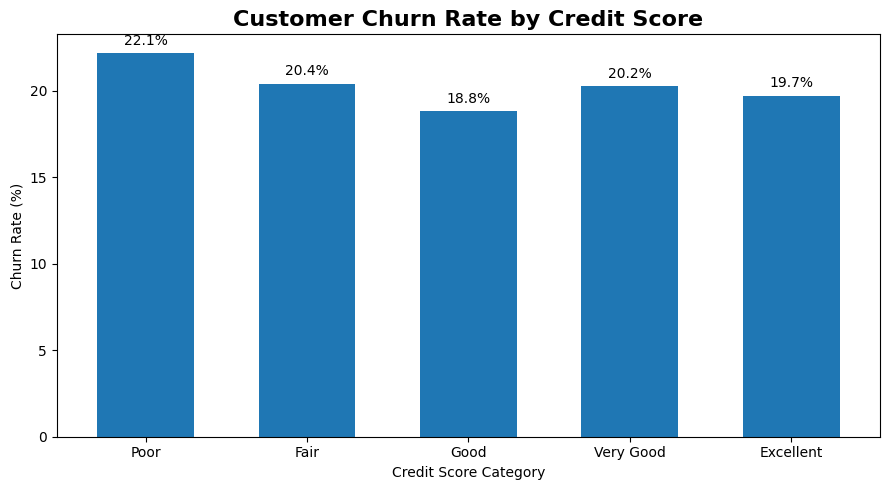

In [57]:
credit_churn = (
    data.groupby(
        "CreditScoreGroup",
        observed=True
    )["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

ax = credit_churn.plot(
    kind="bar",
    width=0.6
)

for i, value in enumerate(credit_churn):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.title(
    "Customer Churn Rate by Credit Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Credit Score Category")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

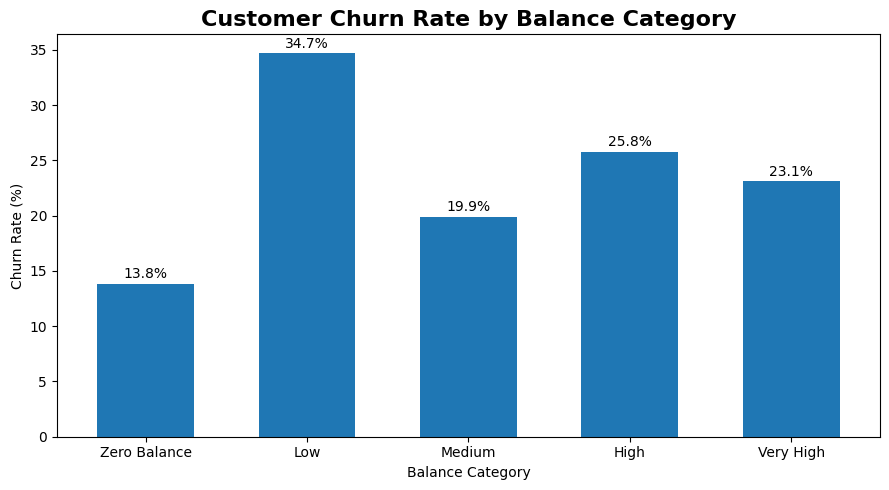

In [58]:
balance_churn = (
    data.groupby(
        "BalanceCategory",
        observed=True
    )["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

ax = balance_churn.plot(
    kind="bar",
    width=0.6
)

for i, value in enumerate(balance_churn):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.title(
    "Customer Churn Rate by Balance Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Balance Category")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

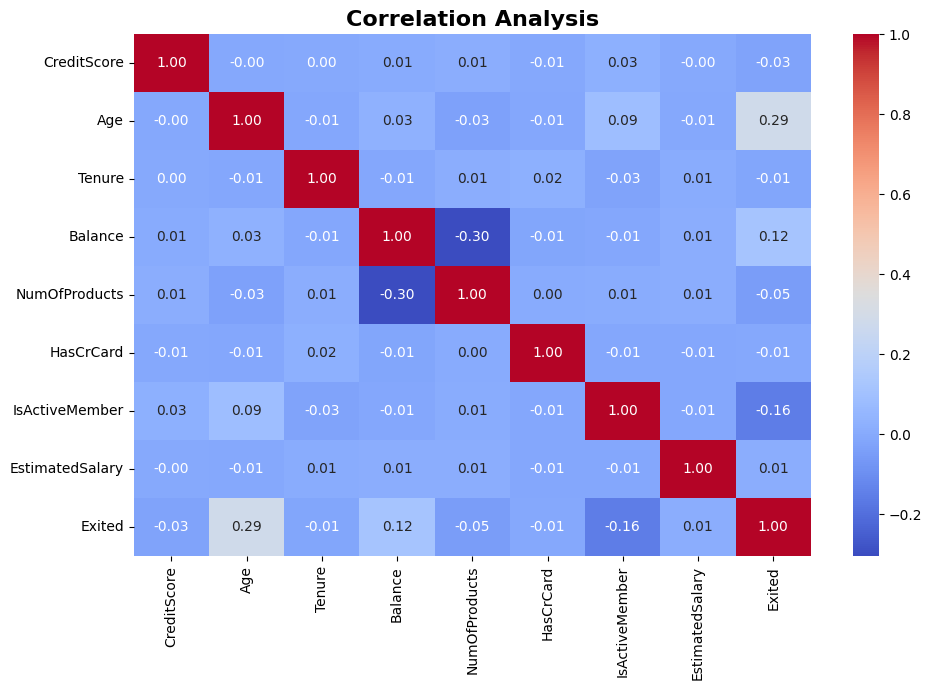

In [59]:
numeric_data = data.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [60]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,CreditScoreGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36–45,Zero Balance,Fair
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36–45,Medium,Fair
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36–45,Very High,Poor
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36–45,Zero Balance,Good
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36–45,High,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,36–45,Zero Balance,Very Good
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,26–35,Medium,Poor
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,36–45,Zero Balance,Good
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,36–45,Medium,Very Good
